EfficientNet-B0 Training

In [12]:
import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)


TensorFlow: 2.13.0


In [13]:
TRAIN_DIR = "../dataset/train"
VAL_DIR   = "../dataset/validation"
TEST_DIR  = "../dataset/test"

IMG_SIZE = 224
BATCH_SIZE = 8   # CPU-safe


In [14]:
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

def efficientnet_preprocessing(img):
    # img comes as RGB array (0..255) from ImageDataGenerator
    img = img.astype(np.uint8)

    # Convert to grayscale (CT)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    # Gaussian blur
    gray = cv2.GaussianBlur(gray, (3,3), 0)

    # Back to 3 channels (0..255 float)
    x = np.stack([gray, gray, gray], axis=-1).astype(np.float32)

    # EfficientNet expected preprocessing (IMPORTANT)
    x = preprocess_input(x)   # maps to EfficientNet's expected range

    return x


In [15]:
train_gen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocessing,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True
)

val_gen  = ImageDataGenerator(preprocessing_function=efficientnet_preprocessing)
test_gen = ImageDataGenerator(preprocessing_function=efficientnet_preprocessing)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary",
    shuffle=False
)

print("Class indices:", train_data.class_indices)


Found 1843 images belonging to 2 classes.
Found 235 images belonging to 2 classes.
Found 437 images belonging to 2 classes.
Class indices: {'Normal': 0, 'Stroke': 1}


In [16]:
class_weights = {0: 0.8477460901563938, 1: 1.218915343915344}
class_weights


{0: 0.8477460901563938, 1: 1.218915343915344}

In [17]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_SIZE = 224

base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3))
)
base.trainable = False  # Phase-1

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(1, activation="sigmoid")(x)

model = Model(base.input, out)

model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [18]:
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/25
231/231 [==============================] - ETA: 0s - loss: 0.7069 - accuracy: 0.5046 - precision: 0.4140 - recall: 0.5000 - auc: 0.5152
Epoch 1: val_auc improved from 0.50163 to 0.72914, saving model to ../models\efficientnetb0_best.h5
231/231 [==============================] - 74s 275ms/step - loss: 0.7069 - accuracy: 0.5046 - precision: 0.4140 - recall: 0.5000 - auc: 0.5152 - val_loss: 0.6765 - val_accuracy: 0.5574 - val_precision: 0.4156 - val_recall: 0.8205 - val_auc: 0.7291 - lr: 1.0000e-04
Epoch 2/25
231/231 [==============================] - ETA: 0s - loss: 0.6730 - accuracy: 0.5817 - precision: 0.4920 - recall: 0.6124 - auc: 0.6181
Epoch 2: val_auc did not improve from 0.72914
231/231 [==============================] - 87s 375ms/step - loss: 0.6730 - accuracy: 0.5817 - precision: 0.4920 - recall: 0.6124 - auc: 0.6181 - val_loss: 0.6274 - val_accuracy: 0.7064 - val_precision: 0.5495 - val_recall: 0.6410 - val_auc: 0.7286 - lr: 1.0000e-04
Epoch 3/25
231/231 [==========

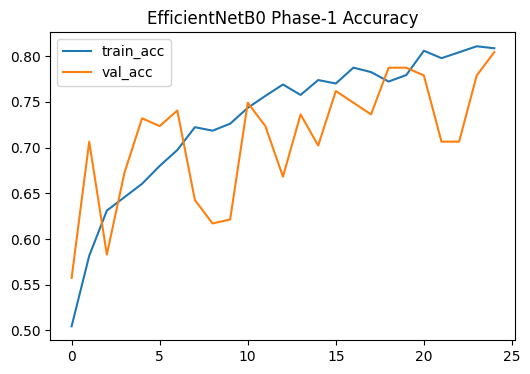

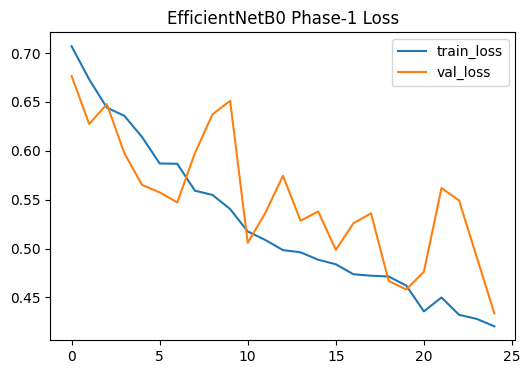

In [19]:
def plot_history(hist, title):
    h = hist.history
    plt.figure(figsize=(6,4))
    plt.plot(h["accuracy"], label="train_acc")
    plt.plot(h["val_accuracy"], label="val_acc")
    plt.title(f"{title} Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(h["loss"], label="train_loss")
    plt.plot(h["val_loss"], label="val_loss")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

plot_history(history1, "EfficientNetB0 Phase-1")


In [20]:
test_metrics = model.evaluate(test_data, verbose=1)
print(dict(zip(model.metrics_names, test_metrics)))


55/55 [==============================] - 22s 390ms/step - loss: 0.5211 - accuracy: 0.7551 - precision: 0.5561 - recall: 0.8769 - auc: 0.8590
{'loss': 0.5211293697357178, 'accuracy': 0.7551487684249878, 'precision': 0.5560975670814514, 'recall': 0.8769230842590332, 'auc': 0.858995258808136}


EfficientNet-B0 Fine-Tuning (Safe, Last Layers Only)

In [21]:
# Unfreeze backbone
base.trainable = True

# Freeze most layers, unfreeze only last 20
for layer in base.layers[:-20]:
    layer.trainable = False

# Keep BatchNorm frozen for stability (VERY IMPORTANT)
for layer in base.layers:
    if "batch_normalization" in layer.name:
        layer.trainable = False

# Check how many layers are trainable
print("Trainable layers:",
      sum([l.trainable for l in base.layers]),
      "/", len(base.layers))


Trainable layers: 20 / 238


In [22]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [23]:
FINE_TUNE_EPOCHS = 8  # CPU-safe; don't exceed 10

history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/8
231/231 [==============================] - ETA: 0s - loss: 0.5899 - accuracy: 0.6810 - precision: 0.5955 - recall: 0.6931 - auc: 0.7510
Epoch 1: val_auc did not improve from 0.90495
231/231 [==============================] - 82s 308ms/step - loss: 0.5899 - accuracy: 0.6810 - precision: 0.5955 - recall: 0.6931 - auc: 0.7510 - val_loss: 0.5183 - val_accuracy: 0.7702 - val_precision: 0.6071 - val_recall: 0.8718 - val_auc: 0.8709 - lr: 1.0000e-05
Epoch 2/8
231/231 [==============================] - ETA: 0s - loss: 0.5607 - accuracy: 0.7075 - precision: 0.6331 - recall: 0.6825 - auc: 0.7839
Epoch 2: val_auc did not improve from 0.90495
231/231 [==============================] - 101s 436ms/step - loss: 0.5607 - accuracy: 0.7075 - precision: 0.6331 - recall: 0.6825 - auc: 0.7839 - val_loss: 0.5570 - val_accuracy: 0.7362 - val_precision: 0.5667 - val_recall: 0.8718 - val_auc: 0.8533 - lr: 1.0000e-05
Epoch 3/8
231/231 [==============================] - ETA: 0s - loss: 0.5319 - accurac

In [24]:
test_metrics_ft = model.evaluate(test_data, verbose=1)
print(dict(zip(model.metrics_names, test_metrics_ft)))


55/55 [==============================] - 10s 183ms/step - loss: 0.5410 - accuracy: 0.7368 - precision: 0.5342 - recall: 0.9000 - auc: 0.8594
{'loss': 0.5409626364707947, 'accuracy': 0.7368420958518982, 'precision': 0.534246563911438, 'recall': 0.8999999761581421, 'auc': 0.859358549118042}


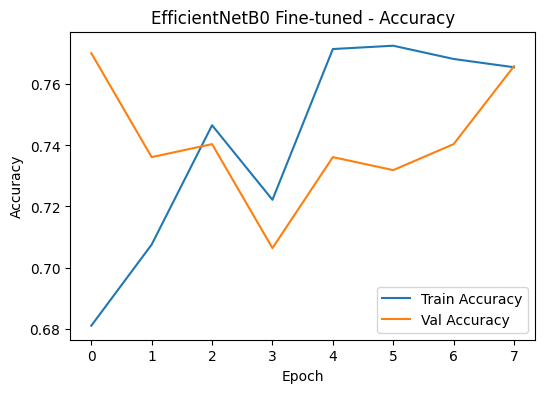

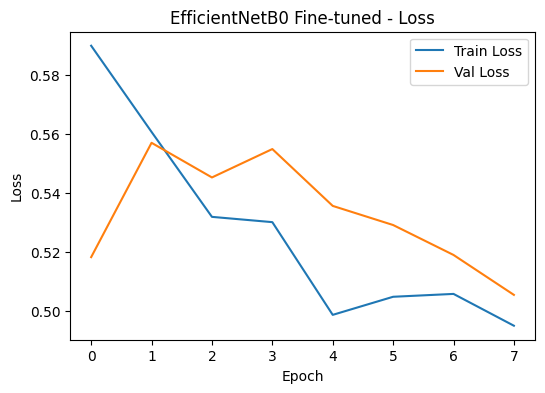

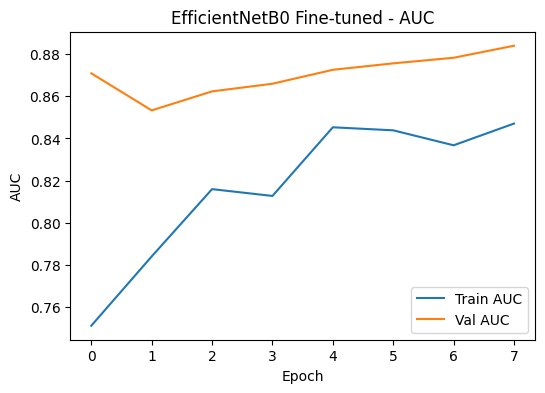

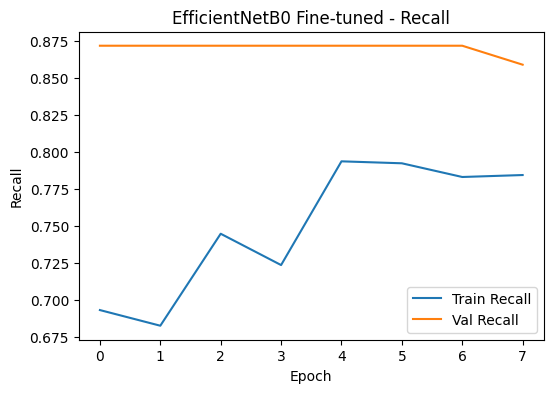

In [25]:
import matplotlib.pyplot as plt

def plot_history_metrics(history, title_prefix="EfficientNetB0 Fine-tuned"):
    h = history.history
    
    # Accuracy
    plt.figure(figsize=(6,4))
    plt.plot(h["accuracy"], label="Train Accuracy")
    plt.plot(h["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # AUC
    plt.figure(figsize=(6,4))
    plt.plot(h["auc"], label="Train AUC")
    plt.plot(h["val_auc"], label="Val AUC")
    plt.title(f"{title_prefix} - AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()
    plt.show()

    # Recall
    plt.figure(figsize=(6,4))
    plt.plot(h["recall"], label="Train Recall")
    plt.plot(h["val_recall"], label="Val Recall")
    plt.title(f"{title_prefix} - Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.legend()
    plt.show()

# Use your fine-tune history variable name:
plot_history_metrics(history_ft, "EfficientNetB0 Fine-tuned")


In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

test_data.reset()

y_prob = model.predict(test_data, verbose=1)
y_pred = (y_prob >= 0.5).astype(int).ravel()
y_true = test_data.classes

print(classification_report(y_true, y_pred, target_names=["Normal", "Stroke"]))


55/55 [==============================] - 11s 179ms/step
              precision    recall  f1-score   support

      Normal       0.94      0.67      0.78       307
      Stroke       0.53      0.90      0.67       130

    accuracy                           0.74       437
   macro avg       0.74      0.78      0.73       437
weighted avg       0.82      0.74      0.75       437



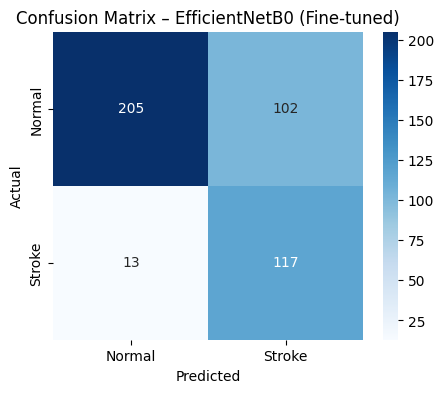

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Stroke"],
    yticklabels=["Normal", "Stroke"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – EfficientNetB0 (Fine-tuned)")
plt.show()


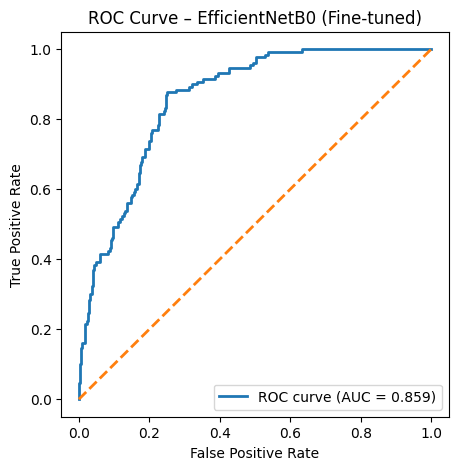

AUC: 0.8594086695063894


In [28]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – EfficientNetB0 (Fine-tuned)")
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc)


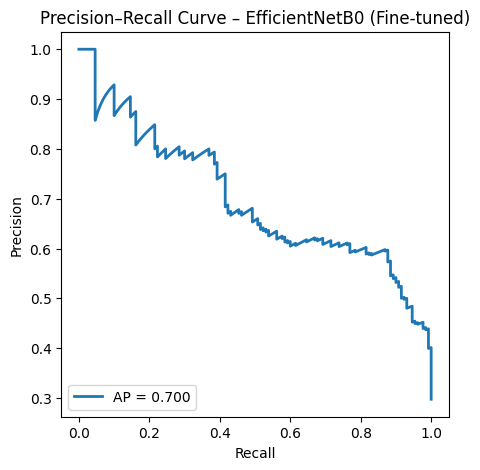

Average Precision (AP): 0.6997094647498666


In [29]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

plt.figure(figsize=(5,5))
plt.plot(recall, precision, lw=2, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – EfficientNetB0 (Fine-tuned)")
plt.legend(loc="lower left")
plt.show()

print("Average Precision (AP):", ap)
